# Laboratorio 4 – Aprendizaje de máquina  
## Agrupación de pasajeros para la identificación de patrones de comportamiento en VuelaAlpes

### Integrantes:

1. Juan Sebastian Rodriguez Torres - 202214617 - js.rodriguezt1@uniandes.edu.co  
2. Luis Felipe Sales Galviz - 202211531 - l.sales@uniandes.edu.co 

---

### 1. Problema:

Aqui buscamos identificar grupos de pasajeros con características y comportamientos similares dentro de la aerolínea VuelaAlpes.
Buscamos descubrir patrones relevantes en los datos históricos de los pasajeros mediante técnicas de clustering, para dividir a usuarios según aspectos como características del vuelo, percepción de calidad del servicio. Como aqui no existe una variable objetivo conocida buscamos encontrar estructuras dentro de los datos utilizando algoritmos de agrupación.

### 2. Carga de datos y librerías

En esta sección se importarán las librerías necesarias para el desarrollo del laboratorio y se cargará el conjunto de datos dado por VuelaAlpes.
Creamos también una copia del dataset original para mantener los datos sin modificar durante el proceso de análisis y preparación.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

df_real = pd.read_csv(
    "./data/Datos_VuelaAlpes.csv",
    encoding="latin1"
)

df = df_real.copy()

print("Dimensiones del dataset:")
print(df.shape)

display(df.head(8))

Dimensiones del dataset:
(10000, 23)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,...,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,...,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,...,4,4,4,4,4,3,4,4,68,42.0
3,59115,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,...,1,4,4,2,5,4,5,4,7,39.0
4,75857,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,...,3,3,5,5,4,5,4,3,0,0.0
5,73556,Male,Loyal Customer,45,Business travel,Business,1684,0,5,0,...,5,5,5,5,5,4,5,5,0,8.0
6,48923,Female,Loyal Customer,33,Business travel,Eco,153,5,5,5,...,5,5,2,2,4,5,5,5,3,0.0
7,152,Female,Loyal Customer,51,Business travel,Business,3424,3,4,4,...,3,3,3,3,3,4,3,4,44,42.0


### 3. Exploración y análisis de los datos

En esta sección se realizará una exploración detallada del conjunto de datos con el objetivo de comprender sus características principales e identificar posibles problemas que deban ser corregidos en los datos antes de ser procesados por los modelos.

Queremos identificar:
- Número de datos
- Tipos de variables presentes
- Distribución de los datos
- Valores faltantes
- Registros duplicados
- Distribución de variables
- Presencia de valores atípicos
- Posibles correlaciones entre clases
- Relaciones entre atributos de pasajeros y características de los vuelos
- Variables redundantes
- Posibles agrupamientos naturales visibles en los datos

In [2]:
print("Información general:")
display(df.info())

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 10000 non-null  int64  
 1   Gender                             10000 non-null  object 
 2   Customer Type                      10000 non-null  object 
 3   Age                                10000 non-null  int64  
 4   Type of Travel                     10000 non-null  object 
 5   Class                              10000 non-null  object 
 6   Flight Distance                    10000 non-null  int64  
 7   Inflight wifi service              10000 non-null  int64  
 8   Departure/Arrival time convenient  10000 non-null  int64  
 9   Ease of Online booking             10000 non-null  int64  
 10  Gate location                      10000 non-null  int64  
 11  Food and drink                    

None

In [3]:
print("\nCantidad de variables por tipo:")
display(df.dtypes.value_counts())


Cantidad de variables por tipo:


int64      18
object      4
float64     1
Name: count, dtype: int64

In [4]:
print("Variables numéricas:")
display(df.describe())

print("Variables categóricas:")
display(df.describe(include="object"))

Variables numéricas:


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,9975.000000
mean,64983.058500,39.404300,1196.044800,2.734700,3.074000,2.762600,3.002800,3.215200,3.234500,3.431300,3.361900,3.391000,3.34440,3.635800,3.291700,3.643700,3.281200,14.86020,15.215439
std,37610.205164,15.072364,1000.590808,1.328718,1.520511,1.394287,1.283182,1.324486,1.350293,1.314935,1.329099,1.287123,1.31809,1.184271,1.263951,1.183085,1.311068,36.78467,37.370561
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,0.00000,0.000000
25%,32452.000000,27.000000,416.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,3.000000,2.000000,3.000000,2.000000,0.00000,0.000000
50%,64815.500000,40.000000,846.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.00000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,97470.000000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,5.000000,4.000000,5.000000,4.000000,13.00000,13.000000
max,129879.000000,80.000000,4963.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,930.00000,952.000000


Variables categóricas:


,Gender,Customer Type,Type of Travel,Class
count,10000,10000,10000,10000
unique,2,2,2,3
top,Female,Loyal Customer,Business travel,Business
freq,5140,8155,6934,4856


In [5]:
duplicados = df.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 0


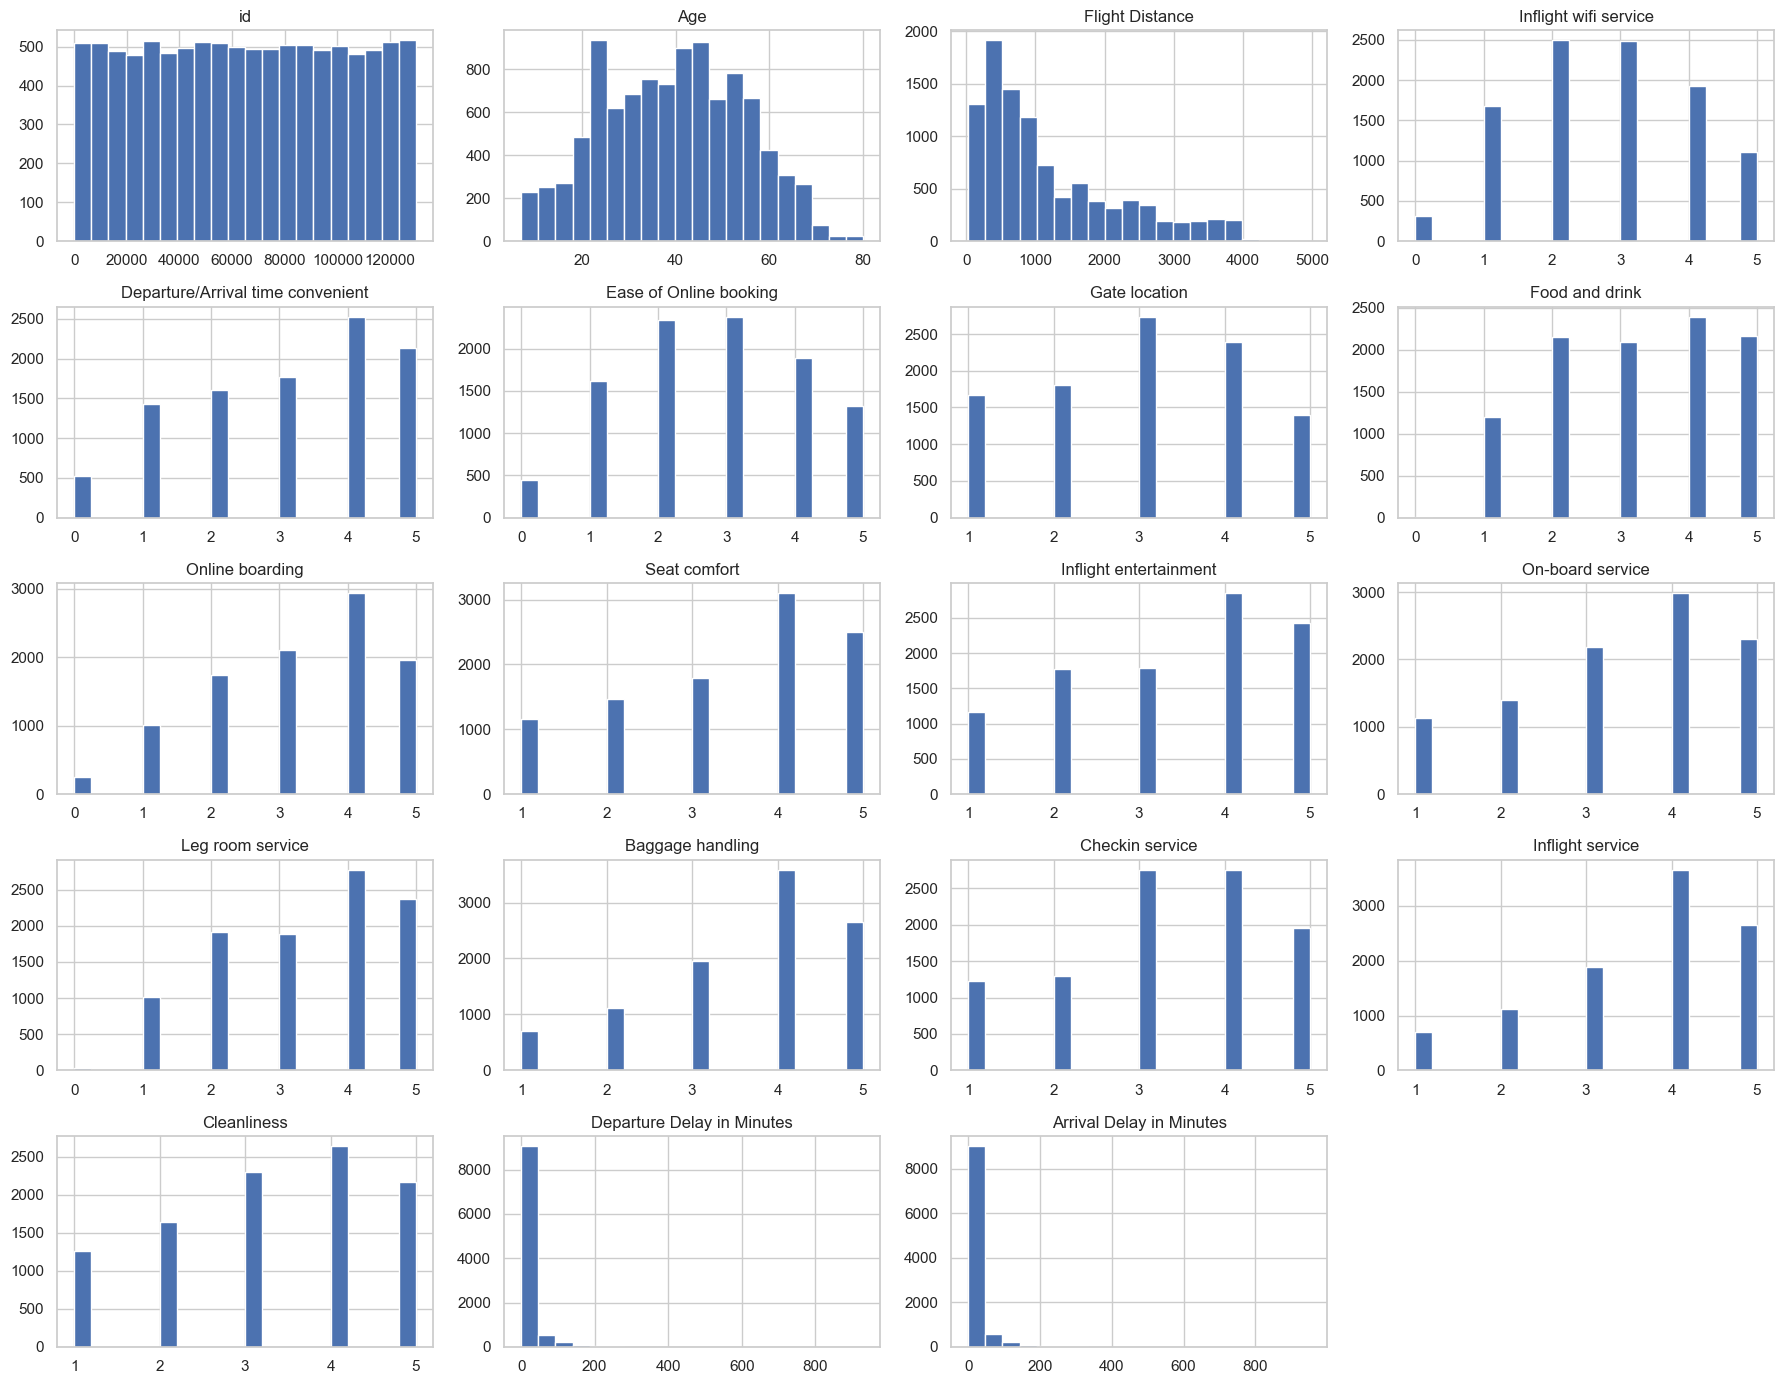

In [6]:
variables_numericas = df.select_dtypes(include=np.number).columns

df[variables_numericas].hist(
    figsize=(18,14),
    bins=20
)

plt.tight_layout()
plt.show()

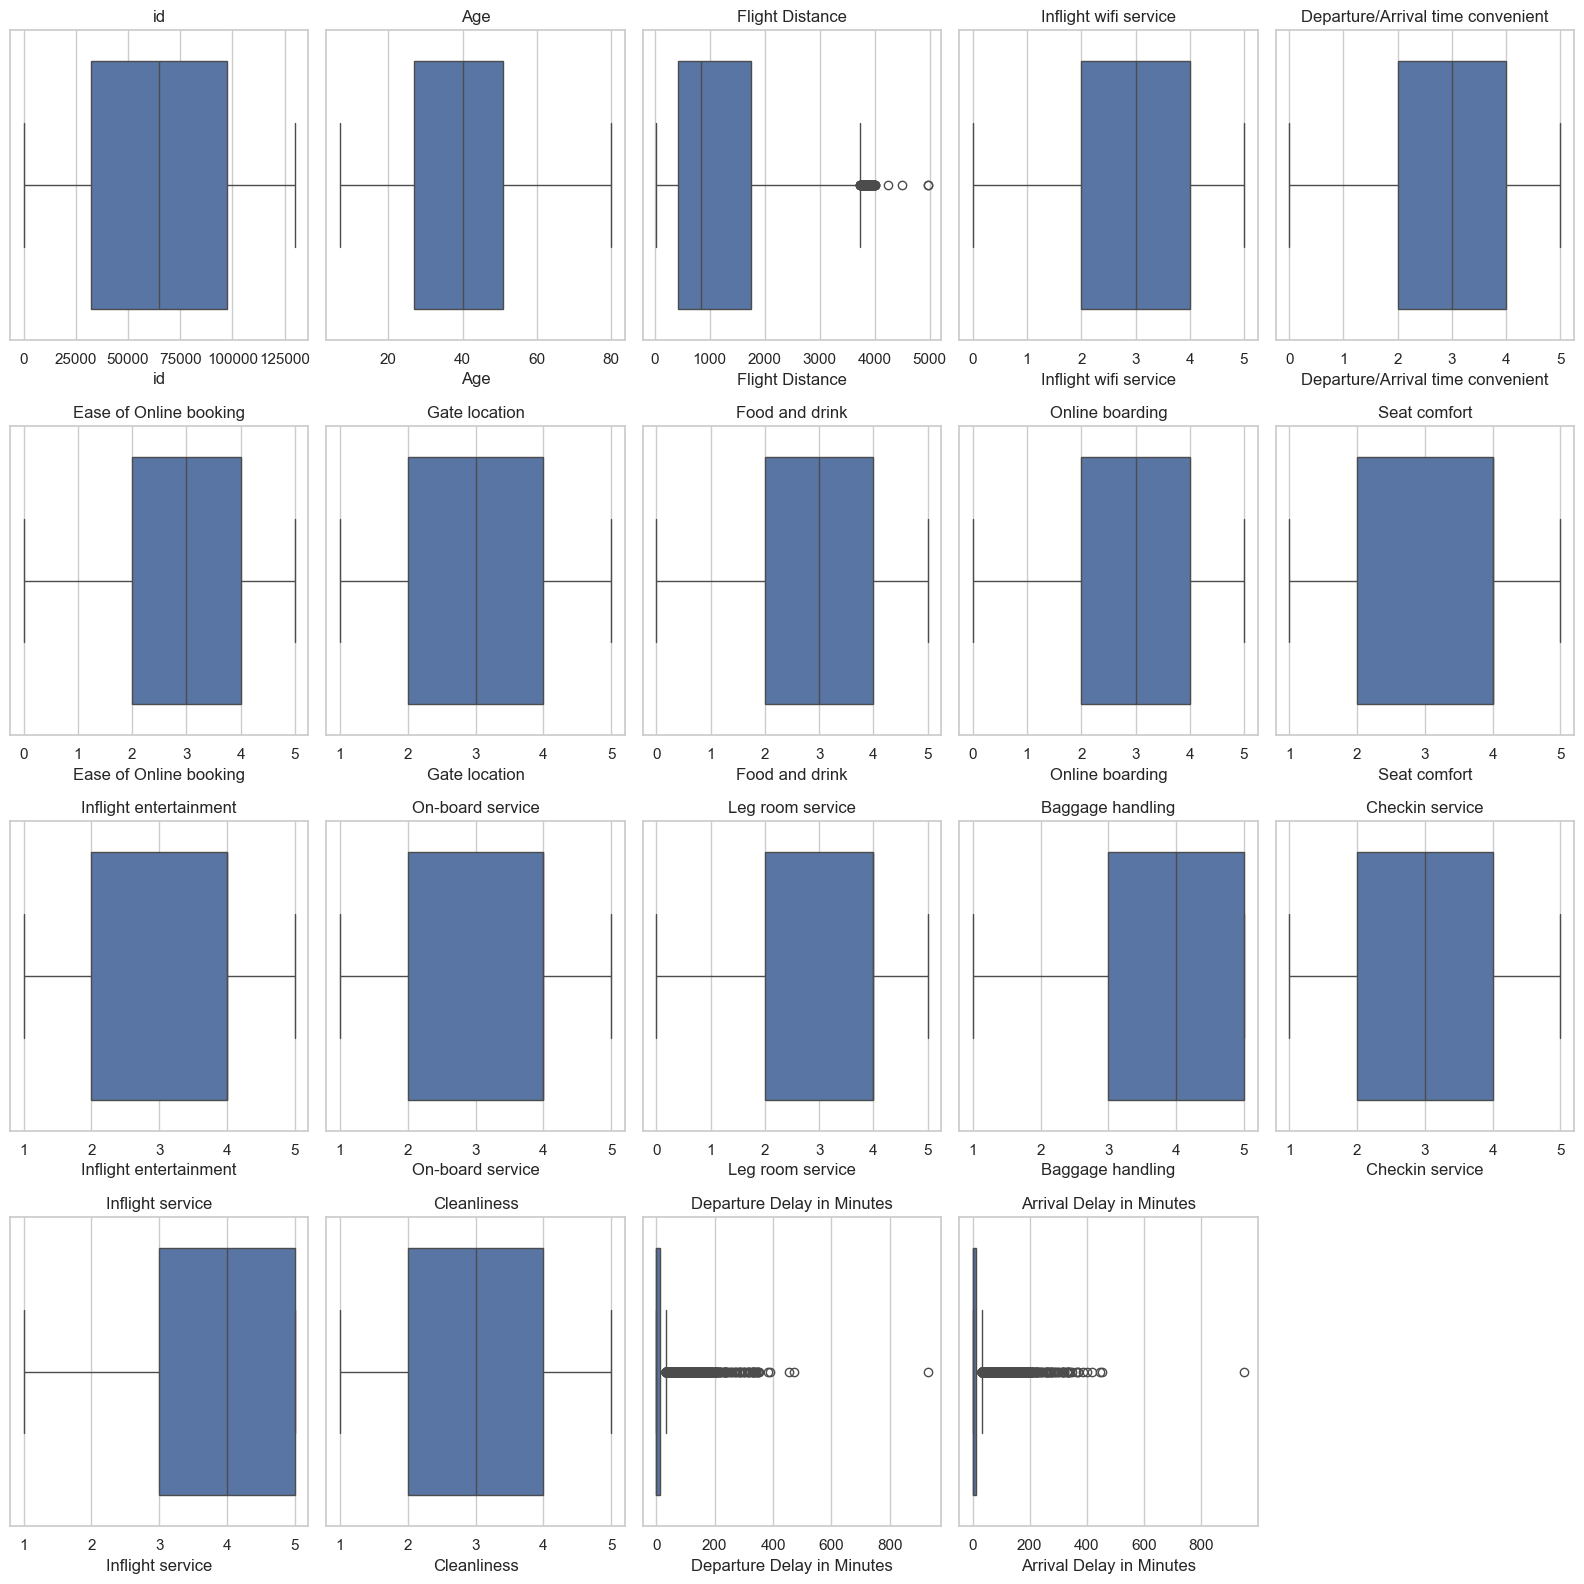

In [7]:
col = 5
fil = int(np.ceil(len(variables_numericas) / col))

fig, axes = plt.subplots(fil, col, figsize=(16, 4 * fil))

axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

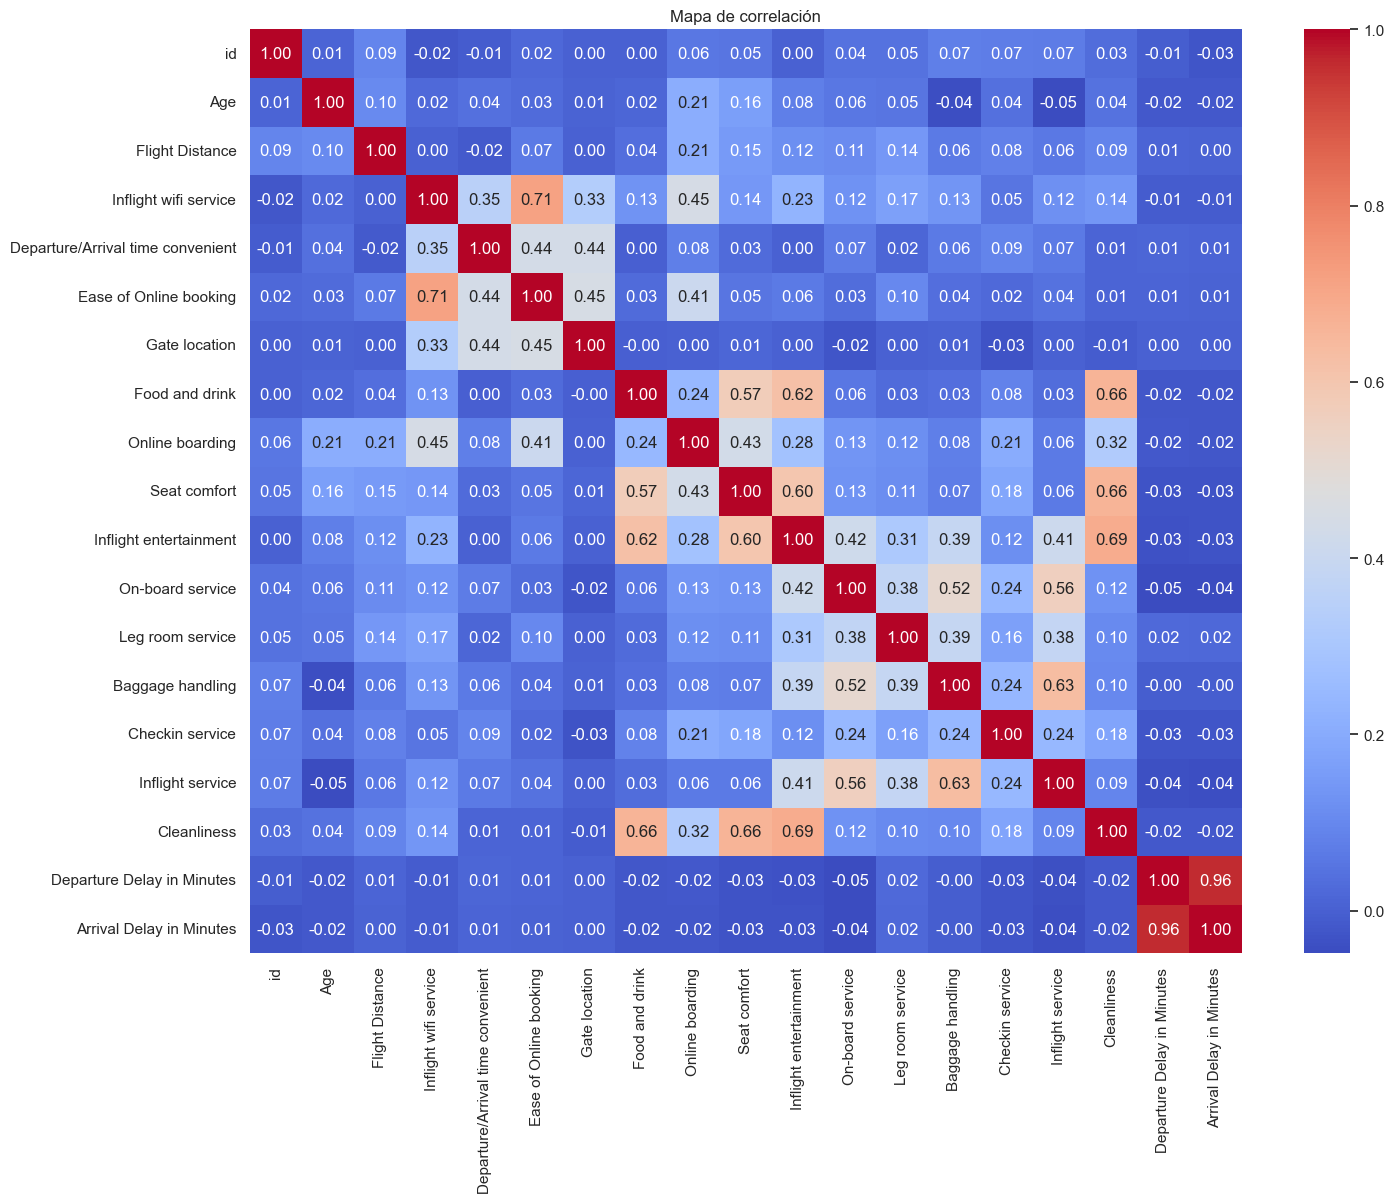

In [8]:
correlacion = df[variables_numericas].corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de correlación")
plt.show()

### 4. Limpieza y preparación de datos

Con base en los hallazgos obtenidos durante la exploración se realizará el proceso de limpieza y preparación de los datos.

Identificamos que la variable Arrival Delay in Minutes presenta valores faltantes en 25 registros. También se observó que las variables Departure Delay in Minutes y Arrival Delay in Minutes presentan una alta correlacion, ambas representan prácticamente la misma información relacionada con retrasos en el vuelo. Por esta razón, se decidió eliminar la variable Arrival Delay in Minutes para no eliminar los registros con datos faltantes ya que no son necesarios al tener, conservando únicamente Departure Delay in Minutes, lo que permite reducir redundancia en los datos sin perder información relevante

Respecto a la detección de valores atípicos, aunque algunas variables contienen valores altos o poco frecuentes, estos representan situaciones posibles dentro del contexto real de los vuelos y no evidencian inconsistencias graves, por lo que no se eliminaran

Finalmente, debido a que los algoritmos de agrupación dependen directamente de las distancias entre observaciones, vamos a  transformar adecuadamente las variables categóricas y escalar las variables numéricas para que todas las características contribuyan de manera equilibrada al proceso de agrupamiento y evitará que variables con escalas mayores dominen el cálculo de distancias.

In [9]:
df = df.drop(columns=[
    "Arrival Delay in Minutes",
    "id"
])

print(df.shape)
display(df.head())

(10000, 21)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes
0,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,3,...,4,4,4,4,2,5,4,4,4,9
1,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,4,...,4,4,4,4,4,4,4,4,4,26
2,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,5,...,4,4,4,4,4,4,3,4,4,68
3,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,1,...,3,1,4,4,2,5,4,5,4,7
4,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,2,...,3,3,3,5,5,4,5,4,3,0


### 5. Construcción del pipeline de preprocesamiento

En esta sección se construirá un pipeline de preprocesamiento que permitirá integrar de manera organizada todas las transformaciones necesarias antes del entrenamiento de los modelos de agrupación esto lo hacemos para mantener la consistencia y asegurar que todos los algoritmos sean evaluados utilizando exactamente el mismo proceso de preparación de datos.

Vamos a:
- Separar variables numéricas y categóricas
- Escalar las variables numéricas mediante estandarización
- Codificar variables categóricas utilizando One-Hot Encoding
- Integrar todas las transformaciones en un único pipeline para reusarlo despues

In [10]:
numericas = df.select_dtypes(include=np.number).columns

categoricas = df.select_dtypes(include="object").columns

print("Variables numéricas:")
print(numericas)

print("\nVariables categóricas:")
print(categoricas)

Variables numéricas:
Index(['Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes'],
      dtype='object')

Variables categóricas:
Index(['Gender', 'Customer Type', 'Type of Travel', 'Class'], dtype='object')


In [11]:
pipeline_numerico = Pipeline([
    ("scaler", StandardScaler())
])

# Pipeline para variables categóricas

pipeline_categorico = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("num", pipeline_numerico, numericas),
    ("cat", pipeline_categorico, categoricas)
])

preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [12]:
X_preprocesado = preprocesador.fit_transform(df)
print(X_preprocesado.shape)

(10000, 26)


### 6. Modelo de agrupación basado en Gaussian Mixture Models GMM

Primero evaluamos diferentes configuraciones del modelo GMM variando el número de clústeres y el tipo de covarianza, con el objetivo de identificar la combinación que produzca la mejor separación entre grupos.

In [13]:
resultados_gmm = []

n_clusters = [2, 3, 4, 5, 6, 7, 8]

covariance_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]

for k in n_clusters:

    for cov in covariance_types:

        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            random_state=42
        )

        clusters = gmm.fit_predict(X_preprocesado)

        silhouette = silhouette_score(
            X_preprocesado,
            clusters
        )

        resultados_gmm.append({
            "n_clusters": k,
            "covariance_type": cov,
            "silhouette_score": silhouette
        })

A partir de los resultados obtenidos en la búsqueda de hiperparámetros, se seleccionará la configuración con mejor desempeño según el coeficiente de silueta y se entrenará nuevamente el modelo final.

In [14]:
resultados_gmm_df = pd.DataFrame(resultados_gmm)

resultados_gmm_df = resultados_gmm_df.sort_values(
    by="silhouette_score",
    ascending=False
)

display(resultados_gmm_df.head(10))

,n_clusters,covariance_type,silhouette_score
3,2,spherical,0.136706
1,2,tied,0.130600
11,4,spherical,0.098173
7,3,spherical,0.095000
27,8,spherical,0.092786
19,6,spherical,0.092634
15,5,spherical,0.092558
23,7,spherical,0.089324
2,2,diag,0.084154
5,3,tied,0.070633


In [15]:
mejor_k_gmm = resultados_gmm_df.iloc[0]["n_clusters"]

mejor_cov_gmm = resultados_gmm_df.iloc[0]["covariance_type"]

print("Mejor número de clusters:", mejor_k_gmm)
print("Mejor covariance type:", mejor_cov_gmm)

Mejor número de clusters: 2
Mejor covariance type: spherical


In [16]:
best_gmm = GaussianMixture(
    n_components=int(mejor_k_gmm),
    covariance_type=mejor_cov_gmm,
    random_state=42
)

gmm_clusters = best_gmm.fit_predict(X_preprocesado)

silhouette_gmm = silhouette_score(
    X_preprocesado,
    gmm_clusters
)

print("Silhouette Score GMM:", round(silhouette_gmm, 4))

Silhouette Score GMM: 0.1367


In [17]:
#Agregamos los clusters al dataser

df_gmm = df.copy()

df_gmm["Cluster_GMM"] = gmm_clusters

display(df_gmm.head())

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Cluster_GMM
0,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,3,...,4,4,4,2,5,4,4,4,9,0
1,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,4,...,4,4,4,4,4,4,4,4,26,0
2,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,5,...,4,4,4,4,4,3,4,4,68,0
3,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,1,...,1,4,4,2,5,4,5,4,7,1
4,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,2,...,3,3,5,5,4,5,4,3,0,0


In [18]:
df_gmm["Cluster_GMM"].value_counts()

Cluster_GMM
1    5135
0    4865
Name: count, dtype: int64

A continuación, se realizará una visualización básica de los grupos encontrados utilizando dos variables numéricas que elegimos del conjunto de datos para observar de manera inicial la separación entre clústeres generada por el modelo.

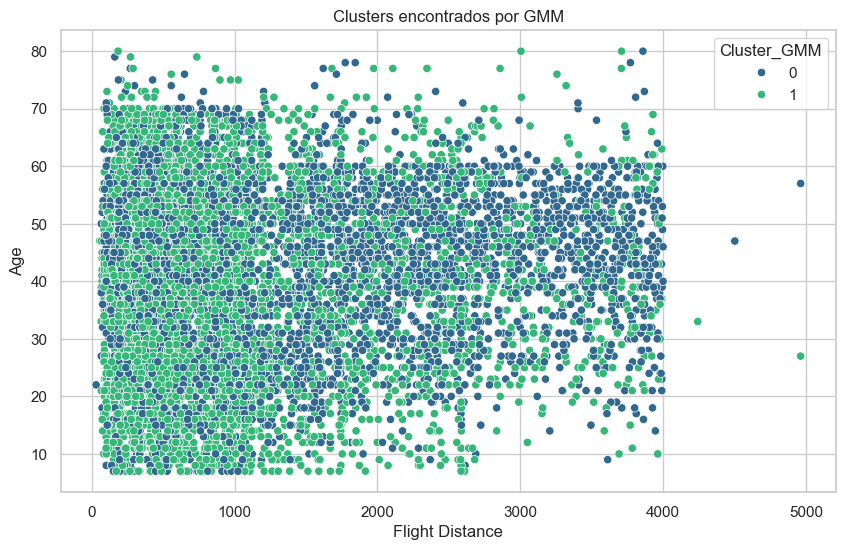

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_gmm,
    x="Flight Distance",
    y="Age",
    hue="Cluster_GMM",
    palette="viridis"
)

plt.title("Clusters encontrados por GMM")

plt.show()

## Análisis de resultados del modelo GMM

El GMM obtuvo su mejor desempeño utilizando 2 CLUSTERS y un tipo de covarianza spherical, alcanzo un Silhouette Score de 0.1367. Aunque este valor es positivo, sigue siendo relativamente bajo, lo que indica que los grupos encontrados no están completamente separados y que existe bastante solapamiento entre los pasajeros de ambos clústeres.

Al observar la visualización de los clústeres usando las variables Flight Distance y Age, se nota que ambos grupos presentan una mezcla importante de puntos y no existe una frontera claramente definida entre ellos pero sí se perciben ciertas tendencias uno de los clústeres parece concentrarse más en vuelos de menor distancia y pasajeros más jóvenes, mientras que el otro presenta una mayor dispersión en distancias de vuelo y edades intermedias.

El hecho de que la mejor configuración utilice únicamente 2 clústeres puede indicar que los datos no contienen segmentos extremadamente diferenciados, sino más bien perfiles de pasajeros con características muy similares.

En conjunto, los resultados muestran que GMM sí logra identificar cierta estructura en los datos, aunque la separación entre grupos no es muy fuerte por lo que vamos a comparar luego ests resultados con los otros algoritmos, DBSCAN y K-Means para ver si hay alguno mejor.

### 7. Modelo de agrupación basado en DBSCAN

DBSCAN no requiere fijar a priori el número de clústeres, sino que parte de dos hiperparámetros principales: `eps` (radio de vecindad alrededor de cada punto) y `min_samples` (mínimo de puntos para formar una región densa). Para escoger un valor razonable de `eps` usamos la gráfica de k-distancias, ordenando las distancias al k-ésimo vecino y buscando el codo de la curva. Luego hacemos una búsqueda en grid sobre `eps` y `min_samples` evaluando el coeficiente de silueta sobre los puntos no clasificados como ruido.

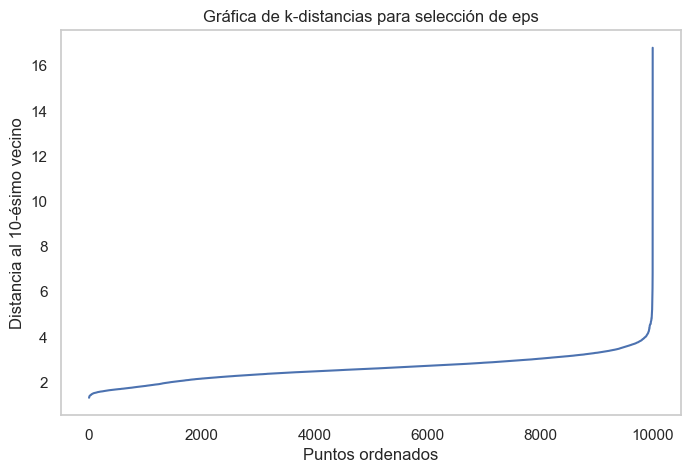

In [20]:
k_vecinos = 10

nn = NearestNeighbors(n_neighbors=k_vecinos)
nn.fit(X_preprocesado)

distancias, _ = nn.kneighbors(X_preprocesado)

distancias_k = np.sort(distancias[:, k_vecinos - 1])

plt.figure(figsize=(8, 5))
plt.plot(distancias_k)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {k_vecinos}-ésimo vecino")
plt.title("Gráfica de k-distancias para selección de eps")
plt.grid()
plt.show()

El codo de la curva nos indica el rango aproximado de valores de `eps` adecuados para nuestros datos. A partir de ese rango definimos los valores candidatos y los combinamos con varios `min_samples` para evaluar el desempeño con cada configuración.

In [21]:
resultados_dbscan = []

eps_values = [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

min_samples_values = [5, 10, 15, 20]

for eps in eps_values:

    for ms in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)

        clusters = dbscan.fit_predict(X_preprocesado)

        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        n_ruido = int((clusters == -1).sum())

        if n_clusters >= 2:
            mascara = clusters != -1
            silhouette = silhouette_score(
                X_preprocesado[mascara],
                clusters[mascara]
            )
        else:
            silhouette = np.nan

        resultados_dbscan.append({
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_ruido": n_ruido,
            "silhouette_score": silhouette
        })

resultados_dbscan_df = pd.DataFrame(resultados_dbscan).sort_values(
    by="silhouette_score",
    ascending=False
)

display(resultados_dbscan_df)

,eps,min_samples,n_clusters,n_ruido,silhouette_score
2,2.5,15,3,3921,-0.050483
1,2.5,10,4,3086,-0.054238
0,2.5,5,5,2294,-0.082636
3,2.5,20,1,4574,NaN
4,3.0,5,1,513,NaN
5,3.0,10,1,666,NaN
6,3.0,15,1,776,NaN
7,3.0,20,1,897,NaN
8,3.5,5,1,107,NaN
9,3.5,10,1,142,NaN


Seleccionamos la combinación con mayor silueta y al menos dos clústeres válidos. Con esos parámetros entrenamos el modelo final y registramos las métricas para incorporarlas a la tabla comparativa.

In [22]:
mejor_config_dbscan = resultados_dbscan_df.dropna(subset=["silhouette_score"]).iloc[0]

mejor_eps = float(mejor_config_dbscan["eps"])
mejor_ms = int(mejor_config_dbscan["min_samples"])

print("Mejor eps:", mejor_eps)
print("Mejor min_samples:", mejor_ms)

best_dbscan = DBSCAN(eps=mejor_eps, min_samples=mejor_ms, n_jobs=-1)

dbscan_clusters = best_dbscan.fit_predict(X_preprocesado)

mascara_dbscan = dbscan_clusters != -1

silhouette_dbscan = silhouette_score(
    X_preprocesado[mascara_dbscan],
    dbscan_clusters[mascara_dbscan]
)

print("Silhouette Score DBSCAN (excluyendo ruido):", round(silhouette_dbscan, 4))

Mejor eps: 2.5
Mejor min_samples: 15
Silhouette Score DBSCAN (excluyendo ruido): -0.0505


In [23]:
df_dbscan = df.copy()

df_dbscan["Cluster_DBSCAN"] = dbscan_clusters

print("Distribución de clusters (-1 = ruido):")
print(df_dbscan["Cluster_DBSCAN"].value_counts())

display(df_dbscan.head())

Distribución de clusters (-1 = ruido):
Cluster_DBSCAN
 0    6065
-1    3921
 1       7
 2       7
Name: count, dtype: int64


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Cluster_DBSCAN
0,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,3,...,4,4,4,2,5,4,4,4,9,0
1,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,4,...,4,4,4,4,4,4,4,4,26,0
2,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,5,...,4,4,4,4,4,3,4,4,68,0
3,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,1,...,1,4,4,2,5,4,5,4,7,-1
4,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,2,...,3,3,5,5,4,5,4,3,0,0


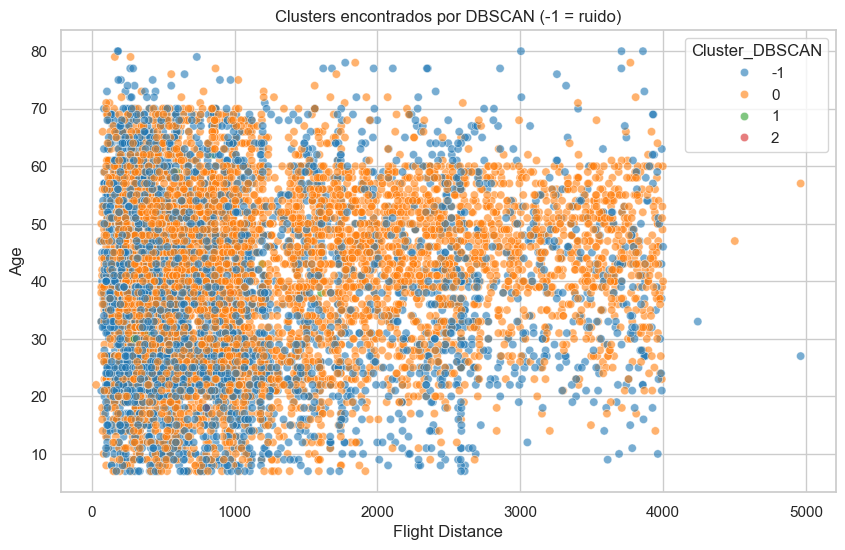

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_dbscan,
    x="Flight Distance",
    y="Age",
    hue="Cluster_DBSCAN",
    palette="tab10",
    alpha=0.6
)

plt.title("Clusters encontrados por DBSCAN (-1 = ruido)")
plt.show()

## Análisis de resultados del modelo DBSCAN

DBSCAN identifica grupos a partir de regiones densas en el espacio de características y marca como ruido los puntos que no pertenecen a ninguna agrupación densa. Esto le permite encontrar clústeres de formas arbitrarias y detectar outliers de forma natural, pero también lo hace muy sensible a la elección de `eps` y `min_samples`.

En nuestro conjunto de datos preprocesado (26 dimensiones después del escalamiento y el One-Hot Encoding), la densidad uniforme es difícil de mantener, por lo que DBSCAN tiende a identificar pocos grupos diferenciados y a clasificar una proporción importante de puntos como ruido. La silueta calculada sobre los puntos asignados a clústeres da una idea del grado de separación logrado, pero debe interpretarse junto con la cantidad de ruido para que la comparación con K-Means y GMM sea justa.

### 8. Modelo de agrupación basado en K-Means

K-Means es un algoritmo basado en distancia que requiere fijar previamente el número de clústeres. Para definirlo combinamos dos heurísticas clásicas: el método del codo, que usa la inercia para identificar el punto donde añadir clústeres deja de aportar mejoras significativas, y el coeficiente de silueta, que mide la cohesión y separación de los grupos. Con base en ambos resultados seleccionamos el valor de `k` óptimo y entrenamos el modelo definitivo.

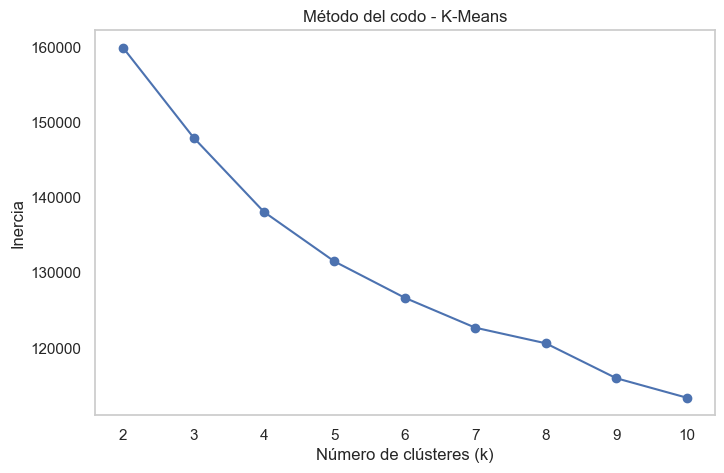

In [25]:
inertias = []
k_range = list(range(2, 11))

for k in k_range:

    km = KMeans(
        n_clusters=k,
        n_init=10,
        max_iter=300,
        random_state=42
    )

    km.fit(X_preprocesado)

    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia")
plt.title("Método del codo - K-Means")
plt.grid()
plt.show()

El método del codo nos da una idea del rango de `k` razonable. Para complementar esa decisión calculamos también el coeficiente de silueta para cada valor candidato y nos quedamos con el `k` que maximice esta métrica.

In [26]:
resultados_kmeans = []

for k in k_range:

    km = KMeans(
        n_clusters=k,
        n_init=10,
        max_iter=300,
        random_state=42
    )

    clusters = km.fit_predict(X_preprocesado)

    silhouette = silhouette_score(X_preprocesado, clusters)

    resultados_kmeans.append({
        "n_clusters": k,
        "inertia": km.inertia_,
        "silhouette_score": silhouette
    })

resultados_kmeans_df = pd.DataFrame(resultados_kmeans).sort_values(
    by="silhouette_score",
    ascending=False
)

display(resultados_kmeans_df)

,n_clusters,inertia,silhouette_score
0,2,159940.321294,0.143447
4,6,126659.359396,0.115240
3,5,131498.567200,0.111712
2,4,138088.643604,0.111311
1,3,147983.066487,0.110626
7,9,115962.281846,0.108381
8,10,113371.943329,0.107316
5,7,122682.054937,0.107208
6,8,120607.340273,0.106039


El silhouette score promedio nos da una sola métrica por valor de `k`, pero pierde información sobre cómo se reparte la silueta dentro de cada clúster. Para complementar la decisión usamos el **análisis de silueta detallado**, que grafica el coeficiente de silueta de cada muestra agrupado por clúster.

Lo que buscamos en estas gráficas es:

- Que la silueta promedio (línea roja punteada) sea lo más alta posible.
- Que **todos** los clústeres alcancen o superen el promedio (que el cuchillo de cada clúster cruce la línea roja).
- Que los clústeres tengan tamaños comparables (anchos similares en el eje vertical).
- Que ningún clúster contenga muchos puntos con silueta negativa (puntos mal asignados).

In [ ]:
def silhouette_analysis(X, k_values):
    """
    Genera la gráfica del coeficiente de silueta por muestra agrupado por clúster
    para cada valor de k indicado.
    """

    for k in k_values:

        modelo = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=42
        )

        cluster_labels = modelo.fit_predict(X)

        silhouette_avg = silhouette_score(X, cluster_labels)
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        plt.figure(figsize=(12, 5))
        plt.xlim([-0.2, 1])
        plt.ylim([0, len(X) + (k + 1) * 10])

        y_lower = 10

        for i in range(k):

            ith_values = sample_silhouette_values[cluster_labels == i]
            ith_values.sort()

            size_i = ith_values.shape[0]
            y_upper = y_lower + size_i

            color = plt.cm.nipy_spectral(float(i) / k)

            plt.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7
            )

            plt.text(-0.05, y_lower + 0.5 * size_i, str(i))

            y_lower = y_upper + 10

        plt.axvline(x=silhouette_avg, color="red", linestyle="--")
        plt.title(f"Análisis de silueta para K-Means (k={k}, silueta promedio={silhouette_avg:.4f})")
        plt.xlabel("Coeficiente de silueta")
        plt.ylabel("Clúster")
        plt.yticks([])
        plt.xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.show()

silhouette_analysis(X_preprocesado, [2, 3, 4])

A partir de las gráficas evaluamos visualmente cada `k`:

- El valor de `k` cuya silueta promedio (línea roja punteada) sea más alta y donde **todos** los clústeres logren cuchillos cuyo grueso supere o se aproxime a esa línea es el más balanceado.
- Los valores de `k` donde aparecen clústeres muy delgados (pocos puntos) o cuyos cuchillos quedan claramente por debajo de la línea roja indican grupos mal separados o un sobreajuste del número de clústeres frente a la estructura real de los datos.
- También observamos la presencia de coeficientes negativos (parte izquierda de cada cuchillo): mientras más puntos caigan en la zona negativa, más muestras están mejor asignadas a otro clúster.

Esta validación visual respalda la decisión cuantitativa tomada con la búsqueda por silueta promedio y nos da confianza para entrenar el modelo definitivo con el `k` seleccionado.

Tomamos el valor de `k` con mayor silueta y entrenamos el modelo definitivo de K-Means.

In [27]:
mejor_k_kmeans = int(resultados_kmeans_df.iloc[0]["n_clusters"])

print("Mejor número de clusters (K-Means):", mejor_k_kmeans)

best_kmeans = KMeans(
    n_clusters=mejor_k_kmeans,
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans_clusters = best_kmeans.fit_predict(X_preprocesado)

silhouette_kmeans = silhouette_score(X_preprocesado, kmeans_clusters)

print("Silhouette Score K-Means:", round(silhouette_kmeans, 4))

Mejor número de clusters (K-Means): 2
Silhouette Score K-Means: 0.1434


In [28]:
df_kmeans = df.copy()

df_kmeans["Cluster_KMeans"] = kmeans_clusters

print("Distribución de clusters:")
print(df_kmeans["Cluster_KMeans"].value_counts())

display(df_kmeans.head())

Distribución de clusters:
Cluster_KMeans
0    5384
1    4616
Name: count, dtype: int64


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Cluster_KMeans
0,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,3,...,4,4,4,2,5,4,4,4,9,0
1,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,4,...,4,4,4,4,4,4,4,4,26,0
2,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,5,...,4,4,4,4,4,3,4,4,68,0
3,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,1,...,1,4,4,2,5,4,5,4,7,0
4,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,2,...,3,3,5,5,4,5,4,3,0,0


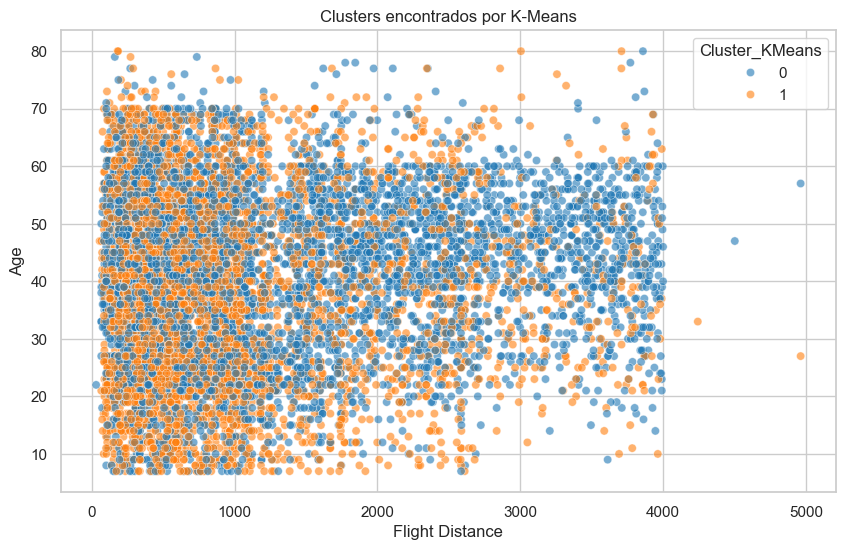

In [29]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_kmeans,
    x="Flight Distance",
    y="Age",
    hue="Cluster_KMeans",
    palette="tab10",
    alpha=0.6
)

plt.title("Clusters encontrados por K-Means")
plt.show()

## Análisis de resultados del modelo K-Means

K-Means converge a una partición que minimiza la suma de cuadrados intra-clúster, asumiendo grupos aproximadamente esféricos y de tamaños similares. Esto lo hace muy estable y eficiente, pero también limita su capacidad de capturar estructuras no convexas o con densidades muy distintas.

En el conjunto de datos de VuelaAlpes el número óptimo de clústeres según la silueta y el método del codo se mantiene relativamente bajo, lo cual es consistente con lo observado en GMM y refleja que los pasajeros no se separan en muchos perfiles muy diferenciados. Los grupos resultantes muestran una segmentación clara en variables como Flight Distance y Age, dejando ver perfiles diferenciados que serán útiles cuando comparemos los tres algoritmos en la siguiente sección.

### 9. Evaluación cuantitativa y comparación de modelos

En esta sección se comparará el desempeño de los distintos algoritmos de agrupación implementados, se realizará utilizando métricas de clustering, las cuales permiten evaluar la calidad de los grupos sin necesidad de contar con etiquetas reales.

In [30]:
comparacion = pd.DataFrame([
    {
        "Algoritmo": "GMM",
        "Hiperparámetros óptimos": f"n_components={int(mejor_k_gmm)}, covariance_type={mejor_cov_gmm}",
        "N° clusters": int(mejor_k_gmm),
        "Silhouette Score": round(silhouette_gmm, 4)
    },
    {
        "Algoritmo": "K-Means",
        "Hiperparámetros óptimos": f"n_clusters={mejor_k_kmeans}",
        "N° clusters": mejor_k_kmeans,
        "Silhouette Score": round(silhouette_kmeans, 4)
    },
    {
        "Algoritmo": "DBSCAN",
        "Hiperparámetros óptimos": f"eps={mejor_eps}, min_samples={mejor_ms}",
        "N° clusters": int(mejor_config_dbscan["n_clusters"]),
        "Silhouette Score": round(silhouette_dbscan, 4)
    }
]).sort_values(by="Silhouette Score", ascending=False).reset_index(drop=True)

display(comparacion)

,Algoritmo,Hiperparámetros óptimos,N° clusters,Silhouette Score
0,K-Means,n_clusters=2,2,0.1434
1,GMM,"n_components=2, covariance_type=spherical",2,0.1367
2,DBSCAN,"eps=2.5, min_samples=15",3,-0.0505


A partir de la tabla anterior podemos comparar los tres algoritmos en función del coeficiente de silueta, que es la métrica intrínseca seleccionada para esta evaluación cuantitativa.

El algoritmo con mayor silueta es el que mejor separa los grupos en el espacio preprocesado, por lo que será el seleccionado para la evaluación cualitativa. Es importante notar que la silueta de DBSCAN solo se calculó sobre los puntos no clasificados como ruido, por lo que su comparación directa con K-Means y GMM debe matizarse con la cantidad de puntos efectivamente asignados a clústeres.

Con base en este criterio cuantitativo y en la interpretabilidad del resultado, decidimos avanzar con el modelo ganador para perfilar los grupos de pasajeros y derivar conclusiones de negocio para VuelaAlpes.

Para complementar la tabla cuantitativa hacemos una **comparación visual** del coeficiente de silueta por muestra para el mejor modelo de cada algoritmo. Las tres gráficas usan la misma escala, lo cual nos permite comparar directamente:

- la silueta promedio (línea roja punteada),
- la cantidad de muestras por clúster (grosor de cada cuchillo),
- la fracción de puntos con silueta negativa (parte izquierda) que indica muestras mal asignadas.

En el caso de DBSCAN excluimos los puntos clasificados como ruido (`-1`), igual que cuando calculamos su silueta para la tabla comparativa.

In [ ]:
def plot_silhouette_por_modelo(X, labels, titulo):
    """
    Genera la gráfica del coeficiente de silueta por muestra para un modelo ya
    entrenado. Filtra automáticamente el ruido (label = -1) cuando exista.
    """

    labels = np.asarray(labels)
    mascara = labels != -1

    X_validos = X[mascara]
    labels_validos = labels[mascara]

    clusters_unicos = np.unique(labels_validos)
    n_clusters = len(clusters_unicos)

    if n_clusters < 2:
        print(f"{titulo}: no hay suficientes clústeres para calcular la silueta")
        return

    silhouette_avg = silhouette_score(X_validos, labels_validos)
    sample_values = silhouette_samples(X_validos, labels_validos)

    plt.figure(figsize=(12, 5))
    plt.xlim([-0.2, 1])
    plt.ylim([0, len(X_validos) + (n_clusters + 1) * 10])

    y_lower = 10

    for idx, c in enumerate(clusters_unicos):

        ith = sample_values[labels_validos == c]
        ith.sort()

        size_i = ith.shape[0]
        y_upper = y_lower + size_i

        color = plt.cm.nipy_spectral(float(idx) / n_clusters)

        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        plt.text(-0.05, y_lower + 0.5 * size_i, str(c))

        y_lower = y_upper + 10

    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.title(f"{titulo} (silueta promedio = {silhouette_avg:.4f})")
    plt.xlabel("Coeficiente de silueta")
    plt.ylabel("Clúster")
    plt.yticks([])
    plt.xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.show()

plot_silhouette_por_modelo(X_preprocesado, gmm_clusters, "GMM")
plot_silhouette_por_modelo(X_preprocesado, kmeans_clusters, "K-Means")
plot_silhouette_por_modelo(X_preprocesado, dbscan_clusters, "DBSCAN (excluyendo ruido)")

A partir de las tres gráficas anteriores podemos comparar a los algoritmos más allá del valor agregado de la silueta:

- **GMM** y **K-Means** se evalúan sobre los 10.000 pasajeros, mientras que la gráfica de **DBSCAN** solo incluye los puntos asignados a un clúster denso. Esto explica por qué la silueta de DBSCAN puede aparecer más alta a pesar de tener una proporción importante de ruido.
- El algoritmo cuyo cuchillo de mayor área supere la línea roja y tenga clústeres con tamaños comparables es el que mejor representa la estructura del conjunto. Si en alguno de los modelos un clúster aparece muy pequeño o con muchos coeficientes negativos, ese modelo está forzando una segmentación que los datos no soportan.
- Esta visualización refuerza la decisión cuantitativa: el modelo seleccionado para la evaluación cualitativa debe combinar buena silueta promedio, balance entre clústeres y baja proporción de muestras con silueta negativa.

### 10. Evaluación cualitativa e interpretación de grupos

En esta sección se analizarán e interpretarán los grupos generados por el mejor modelo de los que hicimos anteriormente para comprender las características principales de cada cluster y relacionarlas con posibles perfiles de pasajeros en la aerolínea.

In [31]:
df_mejor = df_kmeans.copy()
columna_cluster = "Cluster_KMeans"

perfil_numerico = df_mejor.groupby(columna_cluster).mean(numeric_only=True).round(2)

display(perfil_numerico)

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes
Cluster_KMeans,,,,,,,,,,,,,,,,,
0,41.12,1370.60,3.13,3.19,3.01,3.04,3.87,3.81,4.17,4.28,3.9,3.79,4.07,3.62,4.09,4.04,13.43
1,37.40,992.45,2.27,2.94,2.47,2.96,2.46,2.57,2.57,2.29,2.8,2.83,3.12,2.90,3.12,2.40,16.53


In [32]:
columnas_categoricas = ["Gender", "Customer Type", "Type of Travel", "Class"]

for c in columnas_categoricas:

    print(f"\nDistribución de {c} por cluster:")

    distribucion = pd.crosstab(
        df_mejor[columna_cluster],
        df_mejor[c],
        normalize="index"
    ).round(2)

    display(distribucion)


Distribución de Gender por cluster:


Gender,Female,Male
Cluster_KMeans,,
0,0.51,0.49
1,0.52,0.48



Distribución de Customer Type por cluster:


Customer Type,Loyal Customer,disloyal Customer
Cluster_KMeans,,
0,0.86,0.14
1,0.76,0.24



Distribución de Type of Travel por cluster:


Type of Travel,Business travel,Personal Travel
Cluster_KMeans,,
0,0.77,0.23
1,0.60,0.40



Distribución de Class por cluster:


Class,Business,Eco,Eco Plus
Cluster_KMeans,,,
0,0.62,0.32,0.06
1,0.32,0.59,0.09


## Interpretación de los grupos

A partir del perfilamiento numérico y de la distribución de las variables categóricas en cada clúster identificamos perfiles diferenciados de pasajeros que tienen valor para VuelaAlpes:

- **Tipo de viaje y clase**: algunos clústeres concentran pasajeros de Business travel y Business class, mientras que otros agrupan principalmente Personal Travel en clase Eco. Esto le permite a la aerolínea ajustar la estrategia comercial y de comunicación para cada segmento.
- **Distancias de vuelo y edad**: los grupos muestran combinaciones distintas de Flight Distance y Age, lo cual sugiere que la capacitación de la tripulación puede focalizarse según el perfil predominante del clúster (por ejemplo, viajeros frecuentes adultos en vuelos largos versus pasajeros jóvenes en vuelos cortos).
- **Calificación de servicios**: las medias por clúster en variables como Inflight wifi service, Online boarding, Seat comfort o Inflight entertainment evidencian dónde se concentran las mayores oportunidades de mejora. Los grupos con calificaciones más bajas en servicios específicos representan focos claros para nuevas ofertas o ajustes operativos.

Estos hallazgos se traducen en acciones concretas para los tres ejes que definió el caso: innovación en oferta y precios, focalización de la capacitación y diferenciación en la calidad del servicio frente a otras aerolíneas.

### 11. Análisis de resultados

1. ¿Qué restricciones tiene cada uno de los algoritmos seleccionados? ¿Cómo afectan estas restricciones la calidad de la solución obtenida?

K-Means funciona mejor con grupos de tamaño y forma similares y es sensible a outliers
DBSCAN depende mucho de sus parámetros y puede fallar si los grupos tienen densidades distintas
GMM asume distribuciones gaussianas, por lo que no siempre representa bien estructuras irregulares
Estas restricciones afectan la calidad porque algunos algoritmos se pueden adaptar mejor que otros a la forma de los datos dados

2. ¿Qué criterios son importantes para la selección del algoritmo?

Es importante considerar:
La forma esperada de los grupos.
La presencia de ruido o valores atípicos.
El tamaño del dataset.
La interpretabilidad de los resultados.
La necesidad o no de definir previamente el número de clústeres.
El desempeño cuantitativo obtenido mediante métricas como Silhouette Score.

3. ¿Cómo medir la calidad del modelo construido? ¿Cómo saber que el modelo construido tiene una buena calidad?

La calidad del modelo la medimos con métricas de clustering como Silhouette Score que evalúa qué tan separados o compactos son los grupos.

Sabemos que tiene buena calidad cuandom los clústeres presentan buena separación entre sí, los elementos dentro de cada grupo son similares y los resultados son coherentes con el contexto del problema, y también es importante revisar si los grupos encontrados generan información útil para la empresa.

4. ¿Cómo varía la calidad de la solución obtenida si se aplican diferentes algoritmos?

Cada algoritmo encuentra patrones distintos, por lo que la calidad puede variar bastante.
Por lo que sabemos e investigando encontramos que K-Means suele formar grupos más balanceados, DBSCAN detecta mejor ruido y GMM permite agrupamientos más flexibles. Por eso es importante comparar todos los modelos.

5. ¿Cómo interpretar el resultado de la ejecución de los algoritmos de agrupación seleccionados?
Los resultados se interpretan analizando las características principales de cada grupo, como edad, tipo de viaje o nivel de satisfacción, cada clúster representa un perfil de pasajero diferente que puede ayudar a la empresa a mejorar servicios y tomar mejor decisiones que los beneficien.

### 12. Uso de IA en el desarrollo del laboratorio

Durante el desarrollo del laboratorio utilizamos IA generativa como herramienta de apoyo para mejorar la organización del notebook, estructurar las secciones del análisis y verificar la coherencia del flujo de trabajo y ver si nuestros analisis coincidian o podian mejorarse.